In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
import cv2
from keras.layers import Flatten, Dense
from keras.applications.vgg16 import VGG16
from keras.applications.mobilenet_v2 import MobileNetV2
from tensorflow.keras.applications import MobileNetV3Large

In [2]:
mask_data_train = 'Face Mask Dataset/Train'
mask_data_test = 'Face Mask Dataset/Test'
val_data_train = 'Face Mask Dataset/Validation'

In [3]:
img_width = 150
img_height = 150

In [4]:
data_train = tf.keras.utils.image_dataset_from_directory(mask_data_train,
                                                        shuffle=True, 
                                                        image_size=(img_width, img_height),
                                                        batch_size=32, 
                                                        validation_split=False)

Found 20815 files belonging to 2 classes.


In [5]:
data_test = tf.keras.utils.image_dataset_from_directory(mask_data_test,
                                                        shuffle=True, 
                                                        image_size=(img_width, img_height),
                                                        batch_size=32, 
                                                        validation_split=False)

Found 992 files belonging to 2 classes.


In [6]:
val_train = tf.keras.utils.image_dataset_from_directory(val_data_train,
                                                        shuffle=True, 
                                                        image_size=(img_width, img_height),
                                                        batch_size=32, 
                                                        validation_split=False)

Found 800 files belonging to 2 classes.


In [7]:
data_cat = data_train.class_names
data_cat

['WithMask', 'WithoutMask']

In [8]:
data_train

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 150, 150, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>

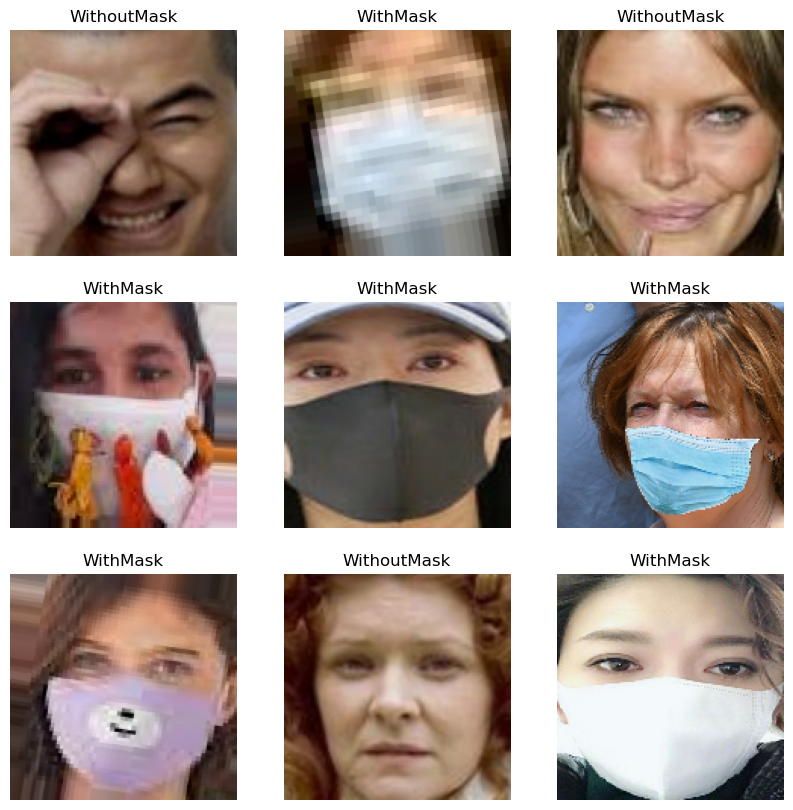

In [9]:
plt.figure(figsize=(10, 10))
for image, labels in data_train.take(1):
    for i in range(9):
        plt.subplot(3,3, i+1)
        plt.imshow(image[i].numpy().astype('uint8'))
        plt.title(data_cat[labels[i]])
        plt.axis('off')

In [10]:
CN_bas = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(150,150,3)
)

In [11]:
CN_bas.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 150, 150, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 150, 150, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 75, 75, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 75, 75, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 75, 75, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 37, 37, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 37, 37, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 37, 37, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 37, 37, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 18, 18, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 18, 18, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 18, 18, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 18, 18, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 9, 9, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 4, 4, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 14,714,688 (56.13 MB)

 Non-trainable params: 0 (0.00 B)

In [12]:
model = Sequential()
model.add(CN_bas)
model.add(Flatten())
model.add(Dense(256, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

In [13]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 4, 4, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     2,097,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,812,353 (64.13 MB)

 Trainable params: 16,812,353 (64.13 MB)

 Non-trainable params: 0 (0.00 B)

In [14]:
CN_bas.trainable = False

In [15]:
def process(image, label):
    image = tf.cast(image/255. , tf.float32)
    return image, label
data_train = data_train.map(process)
val_train = val_train.map(process)

In [16]:
model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.00001), 
            loss = keras.losses.BinaryCrossentropy(), metrics = ['accuracy'])

In [17]:
epochs = 5
history = model.fit(data_train,validation_data=val_train, epochs = epochs)

Epoch 1/5
651/651 ━━━━━━━━━━━━━━━━━━━━ 765s 1s/step - accuracy: 0.9305 - loss: 0.2170 - val_accuracy: 0.9750 - val_loss: 0.0938
Epoch 2/5
651/651 ━━━━━━━━━━━━━━━━━━━━ 782s 1s/step - accuracy: 0.9706 - loss: 0.0930 - val_accuracy: 0.9812 - val_loss: 0.0628
Epoch 3/5
651/651 ━━━━━━━━━━━━━━━━━━━━ 787s 1s/step - accuracy: 0.9754 - loss: 0.0730 - val_accuracy: 0.9837 - val_loss: 0.0483
Epoch 4/5
651/651 ━━━━━━━━━━━━━━━━━━━━ 770s 1s/step - accuracy: 0.9791 - loss: 0.0621 - val_accuracy: 0.9887 - val_loss: 0.0376
Epoch 5/5
651/651 ━━━━━━━━━━━━━━━━━━━━ 799s 1s/step - accuracy: 0.9821 - loss: 0.0549 - val_accuracy: 0.9925 - val_loss: 0.0336


In [18]:
epoch_range = range(epochs)
plt.figure(figsize=(8,8))

<Figure size 800x800 with 0 Axes>

<Figure size 800x800 with 0 Axes>

In [19]:
image = '1.jpg'
image = tf.keras.utils.load_img(image, target_size=(img_width, img_height))
img_arr = tf.keras.utils.array_to_img(image)
img_bat = tf.expand_dims(img_arr, 0)

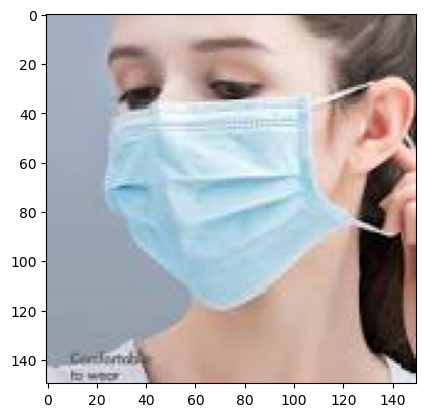

In [20]:
plt.imshow(image)

In [21]:
predict = model.predict(img_bat)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 265ms/step


In [22]:
score = tf.math.sigmoid(predict)

In [23]:
score

<tf.Tensor: shape=(1, 1), dtype=float32, numpy=array([[0.5]], dtype=float32)>

In [24]:
cap = cv2.VideoCapture(0)

In [25]:
def detect_face_mask(face):
    face = cv2.cvtColor(face, cv2.COLOR_BGR2RGB)
    face = cv2.resize(face, (150,150))
    face = face.astype("float32") / 255.0
    face = np.expand_dims(face, axis=0)
    prediction = model.predict(face, verbose=0)[0][0]
    return prediction

In [26]:
def draw_label(img, text, pos, bg_color):
    text_size = cv2.getTextSize(text, cv2.FONT_HERSHEY_SIMPLEX, 1, cv2.FILLED)
    end_x = pos[0] + text_size[0][0] + 2
    end_y = pos[1] + text_size[0][1] - 2

    cv2.rectangle(img, pos, (end_x, end_y), bg_color, cv2.FILLED)
    cv2.putText(img, text, pos, cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 0, 0), 1, cv2.LINE_AA)

In [27]:
haar = cv2.CascadeClassifier('haarcascade_frontalface_default.xml')

In [28]:
def detect_face(img):
    cood = haar.detectMultiScale(img)
    return cood

In [29]:
while True:
    ret, frame = cap.read()
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    faces = haar.detectMultiScale(gray, 1.1, 4)
    for (x, y, w, h) in faces:
        face = frame[y:y+h, x:x+w]
        pred = detect_face_mask(face)
        if pred > 0.5:
            label = "No Mask"
            color = (0,0,255)
        else:
            label = "Mask"
            color = (0,255,0)
        cv2.rectangle(frame, (x,y), (x+w,y+h), color, 2)
        draw_label(frame, label, (x,y-10), color)
    cv2.imshow("Video", frame)
    if cv2.waitKey(1) & 0xFF == ord('x'):
        break
cap.release()
cv2.destroyAllWindows()